<a href="https://colab.research.google.com/github/vikas0510-hub/ai-coach/blob/main/cnn__project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Network Image Classification Project

In [ ]:
! pip install tensorflow

In [ ]:
# Import our dependencies
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl
import tensorflow as tf
import os
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Generate a tf.data.Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Data.zip to Data (1).zip


In [ ]:
! unzip Data.zip

Archive:  Data.zip
  inflating: Data/test/adenocarcinoma/000108 (3).png  
  inflating: Data/test/adenocarcinoma/000109 (2).png  
  inflating: Data/test/adenocarcinoma/000109 (4).png  
  inflating: Data/test/adenocarcinoma/000109 (5).png  
  inflating: Data/test/adenocarcinoma/000112 (2).png  
  inflating: Data/test/adenocarcinoma/000113 (7).png  
  inflating: Data/test/adenocarcinoma/000114 (5).png  
  inflating: Data/test/adenocarcinoma/000114.png  
  inflating: Data/test/adenocarcinoma/000115 (4).png  
  inflating: Data/test/adenocarcinoma/000115 (8).png  
  inflating: Data/test/adenocarcinoma/000115.png  
  inflating: Data/test/adenocarcinoma/000116 (5).png  
  inflating: Data/test/adenocarcinoma/000116 (7).png  
  inflating: Data/test/adenocarcinoma/000116 (9).png  
  inflating: Data/test/adenocarcinoma/000117 (4).png  
  inflating: Data/test/adenocarcinoma/000117 (8).png  
  inflating: Data/test/adenocarcinoma/000117.png  
  inflating: Data/test/adenocarcinoma/000118 (5).png  
  i

In [ ]:
import os
base_dir = 'Data'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
valid_dir = os.path.join(base_dir, 'valid')

### List the folders to see their arrangement

In [ ]:
os.listdir(base_dir)

['valid', 'test', 'train']

### Create train, test and validation datasets

In [ ]:
training_set = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
seed=101,
image_size=(200, 200),
batch_size=32)

Found 613 files belonging to 4 classes.


In [ ]:
testing_set = tf.keras.preprocessing.image_dataset_from_directory(
test_dir,
seed=101,
image_size=(200, 200),
batch_size=32)

Found 315 files belonging to 4 classes.


In [ ]:
valid_set = tf.keras.preprocessing.image_dataset_from_directory(
valid_dir,
seed=101,
image_size=(200, 200),
batch_size=32)

Found 72 files belonging to 4 classes.


## Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
callbacks = [
             EarlyStopping(patience=20)
]

## Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential(
  [
    tf.keras.Input(shape=(200, 200, 3)), # Define input shape explicitly
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
  ]
)

## Build CNN

In [ ]:
model = Sequential([
    #data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    Conv2D(filters=32,kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(filters=32,kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(filters=64,kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(4, activation='softmax') # Corrected to 4 classes for softmax output
])

In [ ]:
# Print all weights
for layer in model.layers:
    weights = layer.get_weights()

    if weights:  # Skip layers without weights
        print(f"\nLayer: {layer.name}")

        for i, w in enumerate(weights):
            print(f"Weight {i}")
            print("Shape:", w.shape)
            print("Data Type:", w.dtype)   # Should be float32
            print(w)

In [ ]:
import numpy as np

all_weights = {}

for layer in model.layers:
    weights = layer.get_weights()

    if weights:
        all_weights[layer.name] = weights

np.save("all_weights_fp32.npy", all_weights, allow_pickle=True)

In [ ]:
weights_dict = np.load("all_weights_fp32.npy", allow_pickle=True).item()

for layer_name, weights in weights_dict.items():
    print(layer_name)
    print(weights[0].shape)

In [ ]:
for layer in model.layers:
    for w in layer.weights:
        print(w.name, w.dtype)

In [ ]:
filepath = 'best_model.h5'

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('best_model.h5')

for layer in model.layers:
    weights = layer.get_weights()

    if weights:
        print(f"\n{layer.name}")
        for w in weights:
            print("Shape:", w.shape)
            print("Dtype:", w.dtype)


efficientnetb3
Shape: (3,)
Dtype: float32
Shape: (3,)
Dtype: float32
Shape: ()
Dtype: int64
Shape: (3, 3, 3, 40)
Dtype: float32
Shape: (40,)
Dtype: float32
Shape: (40,)
Dtype: float32
Shape: (40,)
Dtype: float32
Shape: (40,)
Dtype: float32
Shape: (3, 3, 40, 1)
Dtype: float32
Shape: (40,)
Dtype: float32
Shape: (40,)
Dtype: float32
Shape: (40,)
Dtype: float32
Shape: (40,)
Dtype: float32
Shape: (1, 1, 40, 10)
Dtype: float32
Shape: (10,)
Dtype: float32
Shape: (1, 1, 10, 40)
Dtype: float32
Shape: (40,)
Dtype: float32
Shape: (1, 1, 40, 24)
Dtype: float32
Shape: (24,)
Dtype: float32
Shape: (24,)
Dtype: float32
Shape: (24,)
Dtype: float32
Shape: (24,)
Dtype: float32
Shape: (3, 3, 24, 1)
Dtype: float32
Shape: (24,)
Dtype: float32
Shape: (24,)
Dtype: float32
Shape: (24,)
Dtype: float32
Shape: (24,)
Dtype: float32
Shape: (1, 1, 24, 6)
Dtype: float32
Shape: (6,)
Dtype: float32
Shape: (1, 1, 6, 24)
Dtype: float32
Shape: (24,)
Dtype: float32
Shape: (1, 1, 24, 24)
Dtype: float32
Shape: (24,)
Dtype: 

In [ ]:
fp32_weights = model.get_weights()

In [ ]:
quantized_weights = []

for w in fp32_weights:
    # Check if the maximum absolute value of weights is zero to prevent division by zero
    max_abs_w = np.max(np.abs(w))
    if max_abs_w == 0:
        scale = 0
        q = np.zeros_like(w, dtype=np.int8)
    else:
        scale = 127 / max_abs_w
        q = np.round(w * scale).astype(np.int8)
    quantized_weights.append(q)

In [ ]:
import numpy as np

fp32_weights = model.get_weights()

for layer_idx, w in enumerate(fp32_weights):

    # Quantize to int8
    scale = 127 / np.max(np.abs(w))
    q_weights = np.round(w * scale).astype(np.int8)

    print(f"\nLayer {layer_idx}")
    print("Original Shape:", w.shape)
    print("Quantized Dtype:", q_weights.dtype)
    print(q_weights)


Layer 0
Original Shape: (3,)
Quantized Dtype: int8
[127 119 106]

Layer 1
Original Shape: (3,)
Quantized Dtype: int8
[127 124 125]

Layer 2
Original Shape: ()
Quantized Dtype: int8
0

Layer 3
Original Shape: (3, 3, 3, 40)
Quantized Dtype: int8
[[[[  17    1   41 ...   -1  -17  -16]
   [  66    5  -28 ...   -1 -121  -30]
   [   8    1  -11 ...    1   -9   -8]]

  [[ -25    2   59 ...    4   -2   -8]
   [ -69   -4  -42 ...   -2  -10  -21]
   [ -13    2  -16 ...    2    3   -4]]

  [[   1    0   16 ...    1   -7    0]
   [   1    0  -15 ...    4   -4    3]
   [   2   -1   -2 ...    2   -4    0]]]


 [[[  29  -65   50 ...  -21   -3  -13]
   [  60  -30  -36 ... -110    4  -36]
   [  17   -7  -15 ...   -7   -2   -5]]

  [[ -24   -2   74 ...  -18   27   -5]
   [ -64    0  -48 ... -102  120  -25]
   [ -16    4  -22 ...   -9   11   -2]]

  [[  -1   -1   17 ...   -1    4    0]
   [  -2   -1  -15 ...   -3    6    3]
   [   0   -1    0 ...   -2    3   -1]]]


 [[[   0   -4   14 ...   23  -11    1

/tmp/ipykernel_1227/1897255142.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  scale = 127 / np.max(np.abs(w))
/tmp/ipykernel_1227/1897255142.py:9: RuntimeWarning: invalid value encountered in scalar multiply
  q_weights = np.round(w * scale).astype(np.int8)
/tmp/ipykernel_1227/1897255142.py:9: RuntimeWarning: invalid value encountered in cast
  q_weights = np.round(w * scale).astype(np.int8)



Layer 347
Original Shape: (816,)
Quantized Dtype: int8
[ -48 -127   32  -23   38   10   19   36   11   25   36   23   27   43
   36   40   25   33   41   43   26   28   34  -37   44  -22  -32   27
   29   13  -26   61   36   45   26  -76  -32   -7   23   95   35  -43
   36   36   14   25   27   19   17   25   52   23  -28   35   37   34
   54   34   33   57   34   42   31   16   45    3    9   13  -31   28
   39   26   46   47   38   -5   16   34   -5   18   19   37  -27   29
   47   31   66   39  -29   20  -26  -55   26   36   19   44   75   39
   25  -43   32   36   40   29   35   -4   39   16   62   44   39  -20
   30   18   33   37   17   31  -15   44   24   30   48   34   11   25
   31   17   58  -54   40  -43   26  -44   61  -32   41   18  -10   18
  -15   34   26   34   24   47  -17   28    6  -19   -4   28   85   43
   -3   10   23   19   56   45   10  -14   53   -3  -23  -41   22   35
   41   14   71   -7   33   75   60   33   45   37   25   20    8   19
   31   29   41   50 

In [ ]:
for layer_idx, w in enumerate(model.get_weights()):

    scale = 127 / np.max(np.abs(w))
    q_weights = np.round(w * scale).astype(np.int8)

    print(f"\nLayer {layer_idx}")
    print("Shape:", q_weights.shape)
    print("First 20 weights:")
    print(q_weights.flatten()[:20])


Layer 0
Shape: (3,)
First 20 weights:
[127 119 106]

Layer 1
Shape: (3,)
First 20 weights:
[127 124 125]

Layer 2
Shape: ()
First 20 weights:
[0]

Layer 3
Shape: (3, 3, 3, 40)
First 20 weights:
[ 17   1  41   1  37  14   2  39  20 -20   1   0 -19 -10 -42   4 -21  -4
   7  32]

Layer 4
Shape: (40,)
First 20 weights:
[  2  32 112  30  37  51  28  40  42  48  26 105   8   7 106  93   6  41
  62  57]

Layer 5
Shape: (40,)
First 20 weights:
[  6 -35  24 -39 -50  11 -31  21 -60  22  23  10  17  19   1  32  -3 -58
  14  21]

Layer 6
Shape: (40,)
First 20 weights:
[  0   6 -79  -9   5 -42 -53   0 -20  -6  -1   0   1   0 127 -64 -10  51
  39 -49]

Layer 7
Shape: (40,)
First 20 weights:
[ 11  34  72  54  40  14  92  16  84  22   2   9   4   6 126  52 127  79
  38  49]

Layer 8
Shape: (3, 3, 40, 1)
First 20 weights:
[ 0 -1  3 -2 -7 -1  2 -2  1 -4 -2 -3  4  0 -2 -2 -9  3 -3 -8]

Layer 9
Shape: (40,)
First 20 weights:
[ 33  20  61  12  19  22  10  64  14  30  50 105  38  14  92  60  47  13
  54  3

/tmp/ipykernel_1227/3980717331.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  scale = 127 / np.max(np.abs(w))
/tmp/ipykernel_1227/3980717331.py:4: RuntimeWarning: invalid value encountered in scalar multiply
  q_weights = np.round(w * scale).astype(np.int8)
/tmp/ipykernel_1227/3980717331.py:4: RuntimeWarning: invalid value encountered in cast
  q_weights = np.round(w * scale).astype(np.int8)


In [ ]:
for layer_idx, w in enumerate(model.get_weights()):

    scale = 127 / np.max(np.abs(w))
    q_weights = np.round(w * scale).astype(np.int8)

    print(f"\nLayer {layer_idx}")
    print("FP32:", w.flatten()[:10])
    print("INT8:", q_weights.flatten()[:10])


Layer 0
FP32: [0.485 0.456 0.406]
INT8: [127 119 106]

Layer 1
FP32: [0.229 0.224 0.225]
INT8: [127 124 125]

Layer 2
FP32: [0]
INT8: [0]

Layer 3
FP32: [ 0.3799212   0.01400718  0.8824394   0.01416943  0.8083298   0.29335663
  0.0464774   0.8554688   0.4326048  -0.44157687]
INT8: [ 17   1  41   1  37  14   2  39  20 -20]

Layer 4
FP32: [0.1913209 2.7074034 9.623442  2.5562265 3.127593  4.348222  2.4381876
 3.4623973 3.6115906 4.1241236]
INT8: [  2  32 112  30  37  51  28  40  42  48]

Layer 5
FP32: [ 0.63770825 -3.6502612   2.5161932  -3.9976075  -5.1482773   1.1141102
 -3.2195458   2.1548069  -6.195557    2.2321723 ]
INT8: [  6 -35  24 -39 -50  11 -31  21 -60  22]

Layer 6
FP32: [-1.0869473e-04  5.3624019e-02 -6.7270726e-01 -7.6293588e-02
  4.0184963e-02 -3.5532543e-01 -4.5533198e-01  1.2573927e-03
 -1.7070265e-01 -4.9378924e-02]
INT8: [  0   6 -79  -9   5 -42 -53   0 -20  -6]

Layer 7
FP32: [ 2.172995   6.5312915 13.912926  10.356257   7.816071   2.7316282
 17.810799   3.058472  16

/tmp/ipykernel_1227/3286988778.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  scale = 127 / np.max(np.abs(w))
/tmp/ipykernel_1227/3286988778.py:4: RuntimeWarning: invalid value encountered in scalar multiply
  q_weights = np.round(w * scale).astype(np.int8)
/tmp/ipykernel_1227/3286988778.py:4: RuntimeWarning: invalid value encountered in cast
  q_weights = np.round(w * scale).astype(np.int8)


In [ ]:
with open("quantized_weights.txt", "w") as f:

    for layer_idx, w in enumerate(model.get_weights()):

        scale = 127 / np.max(np.abs(w))
        q_weights = np.round(w * scale).astype(np.int8)

        f.write(f"\nLayer {layer_idx}\n")
        f.write(str(q_weights))
        f.write("\n")

### Compile Model

In [ ]:
model.compile(optimizer='adam',
              #loss=keras.losses.BinaryCrossentropy(from_logits=True),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(), # Corrected for sparse labels
              #loss=keras.losses.mse,
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy()])

### Train the model

In [ ]:
history = model.fit(training_set,validation_data=valid_set, epochs=600,callbacks=callbacks)

Epoch 1/600
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 402ms/step - loss: 1.5955 - sparse_categorical_accuracy: 0.2724 - val_loss: 1.3574 - val_sparse_categorical_accuracy: 0.4306
Epoch 2/600
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 1.2049 - sparse_categorical_accuracy: 0.4388 - val_loss: 1.2416 - val_sparse_categorical_accuracy: 0.4306
Epoch 3/600
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 1.0047 - sparse_categorical_accuracy: 0.5824 - val_loss: 1.0133 - val_sparse_categorical_accuracy: 0.5000
Epoch 4/600
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - loss: 0.7381 - sparse_categorical_accuracy: 0.7194 - val_loss: 0.8346 - val_sparse_categorical_accuracy: 0.5833
Epoch 5/600
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.6871 - sparse_categorical_accuracy: 0.7488 - val_loss: 0.7755 - val_sparse_categorical_accuracy: 0.6944
Epoch 6/600
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.4874 - sparse_categorical_accuracy: 0.8173 - val_loss: 0.8054 - val_sparse_categorical_accuracy: 0.6111
E

# Model attempt 2: use notebook from kaggle as inspiration


link: https://www.kaggle.com/code/prthmgoyl/ensemblemodel-ctscan

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.models import Model, load_model, Sequential
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization

In [ ]:
def define_paths(dir):
    filepaths = []
    labels = []
    folds = os.listdir(dir)
    for fold in folds:
        foldpath = os.path.join(dir, fold)
        filelist = os.listdir(foldpath)
        for file in filelist:
            fpath = os.path.join(foldpath, file)
            filepaths.append(fpath)
            labels.append(fold)
    return filepaths, labels
def define_df(files, classes):
    Fseries = pd.Series(files, name= 'filepaths')
    Lseries = pd.Series(classes, name='labels')
    return pd.concat([Fseries, Lseries], axis= 1)

def create_df(tr_dir, val_dir, ts_dir):
    # train dataframe
    files, classes = define_paths(tr_dir)
    train_df = define_df(files, classes)

    # validation dataframe
    files, classes = define_paths(val_dir)
    valid_df = define_df(files, classes)
    # test dataframe
    files, classes = define_paths(ts_dir)
    test_df = define_df(files, classes)
    return train_df, valid_df, test_df

In [ ]:
def create_gens(train_df, valid_df, test_df, batch_size):
    img_size = (224, 224)
    channels = 3
    img_shape = (img_size[0], img_size[1], channels)
    ts_length = len(test_df)
    test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
    test_steps = ts_length // test_batch_size
    def scalar(img):
        return img
    #class_mode= 'categorical'
    #class_mode='sparse'
    tr_gen = ImageDataGenerator(preprocessing_function= scalar, horizontal_flip= True)
    ts_gen = ImageDataGenerator(preprocessing_function= scalar)
    train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode='categorical',
                                        color_mode= 'rgb', shuffle= True, batch_size= batch_size)
    valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode='categorical',
                                        color_mode= 'rgb', shuffle= True, batch_size= batch_size)
    test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode='categorical',
                                        color_mode= 'rgb', shuffle= False, batch_size= test_batch_size)
    return train_gen, valid_gen, test_gen

In [ ]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def define_paths(dir):
    filepaths = []
    labels = []
    folds = os.listdir(dir)
    for fold in folds:
        foldpath = os.path.join(dir, fold)
        filelist = os.listdir(foldpath)
        for file in filelist:
            fpath = os.path.join(foldpath, file)
            filepaths.append(fpath)
            labels.append(fold)
    return filepaths, labels

def define_df(files, classes):
    Fseries = pd.Series(files, name= 'filepaths')
    Lseries = pd.Series(classes, name='labels')
    return pd.concat([Fseries, Lseries], axis= 1)

def create_df(tr_dir, val_dir, ts_dir):
    # train dataframe
    files, classes = define_paths(tr_dir)
    train_df = define_df(files, classes)

    # validation dataframe
    files, classes = define_paths(val_dir)
    valid_df = define_df(files, classes)
    # test dataframe
    files, classes = define_paths(ts_dir)
    test_df = define_df(files, classes)
    return train_df, valid_df, test_df

def create_gens(train_df, valid_df, test_df, batch_size):
    img_size = (224, 224)
    channels = 3
    img_shape = (img_size[0], img_size[1], channels)
    ts_length = len(test_df)
    test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
    test_steps = ts_length // test_batch_size
    def scalar(img):
        return img
    tr_gen = ImageDataGenerator(preprocessing_function= scalar, horizontal_flip= True)
    ts_gen = ImageDataGenerator(preprocessing_function= scalar)
    train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode='categorical',
                                        color_mode= 'rgb', shuffle= True, batch_size= batch_size)
    valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode='categorical',
                                        color_mode= 'rgb', shuffle= True, batch_size= batch_size)
    test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode='categorical',
                                        color_mode= 'rgb', shuffle= False, batch_size= test_batch_size)
    return train_gen, valid_gen, test_gen

# Get Dataframes
base_dir = 'Data'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'valid') # Assuming 'valid' is test and 'test' is validation based on notebook structure
valid_dir = os.path.join(base_dir, 'test') # Assuming 'valid' is test and 'test' is validation based on notebook structure
train_df, valid_df, test_df = create_df(train_dir, valid_dir, test_dir)

# Get Generators
batch_size = 40
train_gen, valid_gen, test_gen = create_gens(train_df, valid_df, test_df, batch_size)

Found 613 validated image filenames belonging to 4 classes.
Found 315 validated image filenames belonging to 4 classes.
Found 72 validated image filenames belonging to 4 classes.


In [ ]:
train_df

,filepaths,labels
0,Data/train/large.cell.carcinoma_left.hilum_T2_...,large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa
1,Data/train/large.cell.carcinoma_left.hilum_T2_...,large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa
2,Data/train/large.cell.carcinoma_left.hilum_T2_...,large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa
3,Data/train/large.cell.carcinoma_left.hilum_T2_...,large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa
4,Data/train/large.cell.carcinoma_left.hilum_T2_...,large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa
...,...,...
608,Data/train/squamous.cell.carcinoma_left.hilum_...,squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa
609,Data/train/squamous.cell.carcinoma_left.hilum_...,squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa
610,Data/train/squamous.cell.carcinoma_left.hilum_...,squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa
611,Data/train/squamous.cell.carcinoma_left.hilum_...,squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa


## First pass at base CNN model

In [ ]:
from tensorflow.keras.layers import Input

model = Sequential()

model.add(Input(shape=(224,224,3)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,416 (1.48 MB)

 Trainable params: 388,416 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Add dense layers to finish model
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(4))

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,359,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,036 (10.48 MB)

 Trainable params: 2,748,036 (10.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train_gen.labels

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [ ]:
model.compile(optimizer='adam',
              #loss=tf.keras.losses.SparseCategoricalCrossentropy(
              #    from_logits=True
              #    ),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_gen, epochs=100,
                    validation_data=(test_gen))

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 690ms/step - accuracy: 0.3018 - loss: 7.8114 - val_accuracy: 0.3194 - val_loss: 6.2681
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step - accuracy: 0.3181 - loss: 7.9670 - val_accuracy: 0.3194 - val_loss: 6.2681
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 263ms/step - accuracy: 0.3181 - loss: 7.9670 - val_accuracy: 0.3194 - val_loss: 6.2681
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.3181 - loss: 7.9670 - val_accuracy: 0.3194 - val_loss: 6.2681
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.3181 - loss: 7.9670 - val_accuracy: 0.3194 - val_loss: 6.2681
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.3181 - loss: 7.9670 - val_accuracy: 0.3194 - val_loss: 6.2681
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step - accuracy: 0.3181 - loss: 7.9670 - val_accuracy: 0.3194 - val_loss: 6.2681
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.3181 - loss: 7.9670 - val_acc

## First pass at pretrained model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint

# Assuming train_gen and valid_gen are your image data generators

img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))

# Create pre-trained model
base_model = tf.keras.applications.EfficientNetB3(include_top=False,
                                                  weights="imagenet",
                                                  input_shape=img_shape, pooling='max')
for layer in base_model.layers[:-50]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    layer.trainable = True
model = Sequential([
    base_model,
    BatchNormalization(axis=-1),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(class_count, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam()
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              #loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Define filepath to save the best model
filepath = 'best_model.h5'

# Create ModelCheckpoint callback to save the best model based on validation accuracy
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Train the model with the added callback
history = model.fit(
    x=train_gen,
    epochs=100,
    verbose=1,
    validation_data=valid_gen,
    callbacks=[checkpoint]
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5233 - loss: 1.2751   
Epoch 1: val_accuracy improved from None to 0.46032, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.6362 - loss: 1.0882 - val_accuracy: 0.4603 - val_loss: 2.5460
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.8781 - loss: 0.3666
Epoch 2: val_accuracy improved from 0.46032 to 0.69524, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 417ms/step - accuracy: 0.8662 - loss: 0.3584 - val_accuracy: 0.6952 - val_loss: 0.8876
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9511 - loss: 0.1429
Epoch 3: val_accuracy improved from 0.69524 to 0.76508, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 364ms/step - accuracy: 0.9429 - loss: 0.1723 - val_accuracy: 0.7651 - val_loss: 0.8394
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9565 - loss: 0.1041
Epoch 4: val_accuracy improved from 0.76508 to 0.77143, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 407ms/step - accuracy: 0.9608 - loss: 0.0918 - val_accuracy: 0.7714 - val_loss: 0.8656
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9685 - loss: 0.0754
Epoch 5: val_accuracy did not improve from 0.77143
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 305ms/step - accuracy: 0.9674 - loss: 0.0783 - val_accuracy: 0.7365 - val_loss: 1.3158
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9543 - loss: 0.1550
Epoch 6: val_accuracy did not improve from 0.77143
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 368ms/step - accuracy: 0.9527 - loss: 0.1615 - val_accuracy: 0.7175 - val_loss: 2.3142
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9782 - loss: 0.0725
Epoch 7: val_accuracy did not improve from 0.77143
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 303ms/step - accuracy: 0.9772 - loss: 0.0801 - val_accuracy: 0.7365 - val_loss: 1.7668
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.96

...


Epoch 29: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 423ms/step - accuracy: 0.9886 - loss: 0.0453 - val_accuracy: 0.8984 - val_loss: 0.4364
Epoch 30/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9904 - loss: 0.0280
Epoch 30: val_accuracy did not improve from 0.89841
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 303ms/step - accuracy: 0.9886 - loss: 0.0354 - val_accuracy: 0.7937 - val_loss: 1.0983
Epoch 31/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9847 - loss: 0.0364
Epoch 31: val_accuracy did not improve from 0.89841
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 309ms/step - accuracy: 0.9837 - loss: 0.0575 - val_accuracy: 0.8571 - val_loss: 0.6291
Epoch 32/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9882 - loss: 0.0443
Epoch 32: val_accuracy did not improve from 0.89841
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 329ms/step - accuracy: 0.9853 - loss: 0.0570 - val_accuracy: 0.8762 - val_loss: 0.4853
Epoch 33/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accura


Epoch 36: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 409ms/step - accuracy: 0.9918 - loss: 0.0451 - val_accuracy: 0.9048 - val_loss: 0.4847
Epoch 37/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9870 - loss: 0.0755
Epoch 37: val_accuracy did not improve from 0.90476
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 303ms/step - accuracy: 0.9886 - loss: 0.0501 - val_accuracy: 0.8667 - val_loss: 0.6903
Epoch 38/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9930 - loss: 0.0254
Epoch 38: val_accuracy did not improve from 0.90476
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 310ms/step - accuracy: 0.9886 - loss: 0.0429 - val_accuracy: 0.9016 - val_loss: 0.4658
Epoch 39/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9940 - loss: 0.0223
Epoch 39: val_accuracy improved from 0.90476 to 0.92381, saving model to best_model.h5



Epoch 39: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 404ms/step - accuracy: 0.9935 - loss: 0.0176 - val_accuracy: 0.9238 - val_loss: 0.4536
Epoch 40/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9977 - loss: 0.0054
Epoch 40: val_accuracy did not improve from 0.92381
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 297ms/step - accuracy: 0.9967 - loss: 0.0066 - val_accuracy: 0.9175 - val_loss: 0.4817
Epoch 41/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9952 - loss: 0.0138
Epoch 41: val_accuracy did not improve from 0.92381
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 351ms/step - accuracy: 0.9951 - loss: 0.0198 - val_accuracy: 0.9175 - val_loss: 0.4477
Epoch 42/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9921 - loss: 0.0399
Epoch 42: val_accuracy did not improve from 0.92381
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 300ms/step - accuracy: 0.9918 - loss: 0.0396 - val_accuracy: 0.8921 - val_loss: 0.5725
Epoch 43/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accura


Epoch 56: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 400ms/step - accuracy: 0.9967 - loss: 0.0059 - val_accuracy: 0.9270 - val_loss: 0.5088
Epoch 57/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9970 - loss: 0.0077
Epoch 57: val_accuracy did not improve from 0.92698
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 300ms/step - accuracy: 0.9984 - loss: 0.0045 - val_accuracy: 0.9175 - val_loss: 0.5511
Epoch 58/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9970 - loss: 0.0084
Epoch 58: val_accuracy did not improve from 0.92698
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 358ms/step - accuracy: 0.9967 - loss: 0.0080 - val_accuracy: 0.9079 - val_loss: 0.5724
Epoch 59/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9975 - loss: 0.0036
Epoch 59: val_accuracy did not improve from 0.92698
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 299ms/step - accuracy: 0.9984 - loss: 0.0033 - val_accuracy: 0.9175 - val_loss: 0.6028
Epoch 60/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accura


Epoch 89: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 427ms/step - accuracy: 0.9951 - loss: 0.0079 - val_accuracy: 0.9333 - val_loss: 0.5725
Epoch 90/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9997 - loss: 0.0100
Epoch 90: val_accuracy did not improve from 0.93333
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 321ms/step - accuracy: 0.9967 - loss: 0.0707 - val_accuracy: 0.9048 - val_loss: 0.6161
Epoch 91/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9764 - loss: 0.1677
Epoch 91: val_accuracy did not improve from 0.93333
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 336ms/step - accuracy: 0.9869 - loss: 0.0775 - val_accuracy: 0.8063 - val_loss: 0.8381
Epoch 92/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.9946 - loss: 0.0167
Epoch 92: val_accuracy did not improve from 0.93333
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 412ms/step - accuracy: 0.9918 - loss: 0.0306 - val_accuracy: 0.8667 - val_loss: 0.5896
Epoch 93/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accura

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, Average

model= load_model('best_model.h5')

ts_length = len(test_df)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size
train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 1.0000 - loss: 0.0026
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.8750 - loss: 0.4051
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.8889 - loss: 0.5946
Train Loss:  0.002604106208309531
Train Accuracy:  1.0
--------------------
Validation Loss:  0.4051198959350586
Validation Accuracy:  0.875
--------------------
Test Loss:  0.5946051478385925
Test Accuracy:  0.8888888955116272


In [ ]:
from tensorflow.keras.applications import ResNet50

# Assuming train_gen and valid_gen are your image data generators

img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))

# Create pre-trained ResNet50 model
base_model = ResNet50(include_top=False, weights="imagenet", input_shape=img_shape, pooling='max')
# for layer in base_model.layers:
#     layer.trainable = False
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True
model = Sequential([
    base_model,
    BatchNormalization(axis=-1),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(class_count, activation='softmax')
])

optimizer = Adam()  # Using Adam optimizer
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              #loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])

# Define filepath to save the best model
filepath = 'best_model_resnet.h5'

# Create ModelCheckpoint callback to save the best model based on validation accuracy
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Train the model with the added callback
history = model.fit(
    x=train_gen,
    epochs=100,
    verbose=1,
    validation_data=valid_gen,
    callbacks=[checkpoint]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6315 - loss: 1.4982
Epoch 1: val_accuracy improved from None to 0.20952, saving model to best_model_resnet.h5



Epoch 1: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.7292 - loss: 0.9954 - val_accuracy: 0.2095 - val_loss: 47.6230
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9210 - loss: 0.2837
Epoch 2: val_accuracy did not improve from 0.20952
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 342ms/step - accuracy: 0.9266 - loss: 0.2101 - val_accuracy: 0.1714 - val_loss: 37.9533
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9516 - loss: 0.1226
Epoch 3: val_accuracy improved from 0.20952 to 0.54921, saving model to best_model_resnet.h5



Epoch 3: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 417ms/step - accuracy: 0.9527 - loss: 0.1183 - val_accuracy: 0.5492 - val_loss: 4.6414
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9783 - loss: 0.0804
Epoch 4: val_accuracy improved from 0.54921 to 0.70476, saving model to best_model_resnet.h5



Epoch 4: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 382ms/step - accuracy: 0.9723 - loss: 0.0886 - val_accuracy: 0.7048 - val_loss: 3.0086
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9806 - loss: 0.0661
Epoch 5: val_accuracy improved from 0.70476 to 0.72381, saving model to best_model_resnet.h5



Epoch 5: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 421ms/step - accuracy: 0.9788 - loss: 0.0584 - val_accuracy: 0.7238 - val_loss: 1.5146
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9923 - loss: 0.0354
Epoch 6: val_accuracy did not improve from 0.72381
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 348ms/step - accuracy: 0.9886 - loss: 0.0488 - val_accuracy: 0.7238 - val_loss: 1.3496
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9975 - loss: 0.0188
Epoch 7: val_accuracy improved from 0.72381 to 0.73016, saving model to best_model_resnet.h5


...


Epoch 8: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 403ms/step - accuracy: 0.9951 - loss: 0.0172 - val_accuracy: 0.8000 - val_loss: 0.8698
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9965 - loss: 0.0106
Epoch 9: val_accuracy improved from 0.80000 to 0.83492, saving model to best_model_resnet.h5



Epoch 9: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 376ms/step - accuracy: 0.9967 - loss: 0.0090 - val_accuracy: 0.8349 - val_loss: 0.5986
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9826 - loss: 0.2880
Epoch 10: val_accuracy did not improve from 0.83492
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 385ms/step - accuracy: 0.9788 - loss: 0.2633 - val_accuracy: 0.2349 - val_loss: 36.3293
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9646 - loss: 0.6706
Epoch 11: val_accuracy did not improve from 0.83492
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 338ms/step - accuracy: 0.9625 - loss: 0.5700 - val_accuracy: 0.1714 - val_loss: 101.9170
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9719 - loss: 0.0626
Epoch 12: val_accuracy did not improve from 0.83492
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 380ms/step - accuracy: 0.9690 - loss: 0.1053 - val_accuracy: 0.1714 - val_loss: 92.5878
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/st


Epoch 48: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 383ms/step - accuracy: 0.9951 - loss: 0.0168 - val_accuracy: 0.8413 - val_loss: 1.0215
Epoch 49/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.9955 - loss: 0.0066
Epoch 49: val_accuracy improved from 0.84127 to 0.85397, saving model to best_model_resnet.h5



Epoch 49: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 433ms/step - accuracy: 0.9935 - loss: 0.0118 - val_accuracy: 0.8540 - val_loss: 0.9190
Epoch 50/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9947 - loss: 0.0061
Epoch 50: val_accuracy did not improve from 0.85397
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 338ms/step - accuracy: 0.9935 - loss: 0.0087 - val_accuracy: 0.7841 - val_loss: 1.7176
Epoch 51/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.9984 - loss: 0.0064
Epoch 51: val_accuracy did not improve from 0.85397
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 376ms/step - accuracy: 0.9984 - loss: 0.0062 - val_accuracy: 0.7524 - val_loss: 2.0478
Epoch 52/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9957 - loss: 0.0120
Epoch 52: val_accuracy did not improve from 0.85397
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 338ms/step - accuracy: 0.9951 - loss: 0.0142 - val_accuracy: 0.7587 - val_loss: 1.7868
Epoch 53/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step -


Epoch 62: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 425ms/step - accuracy: 0.9951 - loss: 0.0373 - val_accuracy: 0.8730 - val_loss: 0.6869
Epoch 63/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9968 - loss: 0.0161
Epoch 63: val_accuracy did not improve from 0.87302
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 344ms/step - accuracy: 0.9935 - loss: 0.0192 - val_accuracy: 0.7619 - val_loss: 1.4761
Epoch 64/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9844 - loss: 0.3070
Epoch 64: val_accuracy did not improve from 0.87302
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 375ms/step - accuracy: 0.9886 - loss: 0.1198 - val_accuracy: 0.8190 - val_loss: 1.1696
Epoch 65/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9989 - loss: 0.0040
Epoch 65: val_accuracy did not improve from 0.87302
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step - accuracy: 0.9951 - loss: 0.0119 - val_accuracy: 0.8222 - val_loss: 1.0407
Epoch 66/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step -

In [ ]:
import tensorflow as tf

# Load best trained model
model = tf.keras.models.load_model('best_model_resnet.h5')

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable optimization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert
tflite_model = converter.convert()

# Save
with open("resnet50_int8.h5", "wb") as f:
    f.write(tflite_model)

print("INT8 Quantized Model Saved")

Saved artifact at '/tmp/tmp3jp2olr0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140280008942672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140280008943824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140275800996944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140275800997712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140275800991184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140275800997328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140275800997520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140275800995792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140275783451664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140275783450704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1402758009963

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path='resnet50_int8.h5')
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Helper function to evaluate TFLite model
def evaluate_tflite_model(interpreter, data_generator):
    all_predictions = []
    all_true_labels = []

    # Determine number of steps for the generator to avoid partial batches issues
    steps = data_generator.samples // data_generator.batch_size
    if data_generator.samples % data_generator.batch_size != 0:
        steps += 1 # Add a step for the last partial batch

    input_shape = input_details[0]['shape']
    input_dtype = input_details[0]['dtype']

    # Reset the generator to ensure evaluation starts from the beginning
    data_generator.reset()

    for _ in range(steps):
        images, labels_one_hot = next(data_generator)

        # Iterate through each image in the batch and predict individually
        for i in range(images.shape[0]):
            # Extract a single image from the batch and add a batch dimension of 1
            single_image = tf.expand_dims(images[i], axis=0)

            # Resize and cast images to the expected input type and shape for TFLite
            input_data = tf.image.resize(single_image, (input_shape[1], input_shape[2]))
            input_data = tf.cast(input_data, input_dtype)

            # Set the tensor to the input data.
            interpreter.set_tensor(input_details[0]['index'], input_data)

            # Invoke inference.
            interpreter.invoke()

            # Get the output tensor.
            output_data = interpreter.get_tensor(output_details[0]['index'])

            all_predictions.extend(np.argmax(output_data, axis=1))
            all_true_labels.extend(np.argmax(tf.expand_dims(labels_one_hot[i], axis=0), axis=1))

    # Calculate accuracy
    accuracy = accuracy_score(all_true_labels, all_predictions)
    # TFLite interpreter does not directly provide a loss value. Return 0.0 as a placeholder.
    return [0.0, accuracy]

# Evaluate on train, valid, test sets using the TFLite model
train_score = evaluate_tflite_model(interpreter, train_gen)
valid_score = evaluate_tflite_model(interpreter, valid_gen)
test_score = evaluate_tflite_model(interpreter, test_gen)


print("Train Loss: ", train_score[0]) # Placeholder loss for TFLite evaluation
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0]) # Placeholder loss for TFLite evaluation
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0]) # Placeholder loss for TFLite evaluation
print("Test Accuracy: ", test_score[1])

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Train Loss:  0.0
Train Accuracy:  0.9918433931484503
--------------------
Validation Loss:  0.0
Validation Accuracy:  0.8698412698412699
--------------------
Test Loss:  0.0
Test Accuracy:  0.8472222222222222


In [ ]:
from tensorflow.keras.applications import InceptionV3
# Assuming train_gen and valid_gen are your image data generators

img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))

# Create pre-trained InceptionV3 model
base_model = InceptionV3(include_top=False, weights="imagenet", input_shape=img_shape, pooling='max')
for layer in base_model.layers[:-50]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    layer.trainable = True
model = Sequential([
    base_model,
    BatchNormalization(axis=-1),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(class_count, activation='softmax')
])

optimizer = Adam()  # Using Adam optimizer
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              #loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Define filepath to save the best model
filepath = 'best_model_inceptionv3.h5'

# Create ModelCheckpoint callback to save the best model based on validation accuracy
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Train the model with the added callback
history = model.fit(
    x=train_gen,
    epochs=100,
    verbose=1,
    validation_data=valid_gen,
    callbacks=[checkpoint]
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4990 - loss: 2.2725
Epoch 1: val_accuracy improved from None to 0.17143, saving model to best_model_inceptionv3.h5



Epoch 1: finished saving model to best_model_inceptionv3.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.5595 - loss: 1.9910 - val_accuracy: 0.1714 - val_loss: 45.7558
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.7245 - loss: 0.9394
Epoch 2: val_accuracy did not improve from 0.17143
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 350ms/step - accuracy: 0.7374 - loss: 0.9226 - val_accuracy: 0.1714 - val_loss: 54.5541
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.8087 - loss: 0.5115
Epoch 3: val_accuracy did not improve from 0.17143
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 316ms/step - accuracy: 0.8075 - loss: 0.5243 - val_accuracy: 0.1714 - val_loss: 24.9267
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.8658 - loss: 0.3959
Epoch 4: val_accuracy improved from 0.17143 to 0.30476, saving model to best_model_inceptionv3.h5



Epoch 4: finished saving model to best_model_inceptionv3.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 445ms/step - accuracy: 0.8515 - loss: 0.4735 - val_accuracy: 0.3048 - val_loss: 7.3065
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.8648 - loss: 0.5261
Epoch 5: val_accuracy improved from 0.30476 to 0.42857, saving model to best_model_inceptionv3.h5



Epoch 5: finished saving model to best_model_inceptionv3.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 748ms/step - accuracy: 0.8467 - loss: 0.5469 - val_accuracy: 0.4286 - val_loss: 8.5893
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9012 - loss: 0.3196
Epoch 6: val_accuracy did not improve from 0.42857
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 374ms/step - accuracy: 0.8989 - loss: 0.2855 - val_accuracy: 0.3905 - val_loss: 2.9499
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9293 - loss: 0.2562
Epoch 7: val_accuracy did not improve from 0.42857
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 375ms/step - accuracy: 0.9005 - loss: 0.3427 - val_accuracy: 0.2667 - val_loss: 6.7429
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9198 - loss: 0.2920
Epoch 8: val_accuracy did not improve from 0.42857
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 309ms/step - accuracy: 0.9184 - loss: 0.3090 - val_accuracy: 0.3651 - val_loss: 4.4715
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - a


Epoch 10: finished saving model to best_model_inceptionv3.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 367ms/step - accuracy: 0.9331 - loss: 0.2824 - val_accuracy: 0.4508 - val_loss: 4.2512
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.9169 - loss: 0.2481
Epoch 11: val_accuracy improved from 0.45079 to 0.50476, saving model to best_model_inceptionv3.h5


...


Epoch 22: finished saving model to best_model_inceptionv3.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 389ms/step - accuracy: 0.9494 - loss: 0.1167 - val_accuracy: 0.6603 - val_loss: 1.6330
Epoch 23/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9707 - loss: 0.0771
Epoch 23: val_accuracy did not improve from 0.66032
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 315ms/step - accuracy: 0.9674 - loss: 0.0928 - val_accuracy: 0.6349 - val_loss: 1.6512
Epoch 24/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9916 - loss: 0.0335
Epoch 24: val_accuracy did not improve from 0.66032
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 308ms/step - accuracy: 0.9869 - loss: 0.0394 - val_accuracy: 0.6063 - val_loss: 1.6592
Epoch 25/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.9941 - loss: 0.0184
Epoch 25: val_accuracy did not improve from 0.66032
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 362ms/step - accuracy: 0.9902 - loss: 0.0367 - val_accuracy: 0.6540 - val_loss: 1.4563
Epoch 26/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/s


Epoch 27: finished saving model to best_model_inceptionv3.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 409ms/step - accuracy: 0.9951 - loss: 0.0166 - val_accuracy: 0.6921 - val_loss: 1.3110
Epoch 28/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9979 - loss: 0.0133
Epoch 28: val_accuracy did not improve from 0.69206
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 315ms/step - accuracy: 0.9967 - loss: 0.0205 - val_accuracy: 0.6921 - val_loss: 1.3248
Epoch 29/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9973 - loss: 0.0142
Epoch 29: val_accuracy did not improve from 0.69206
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 357ms/step - accuracy: 0.9984 - loss: 0.0100 - val_accuracy: 0.6921 - val_loss: 1.4315
Epoch 30/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9939 - loss: 0.0070
Epoch 30: val_accuracy did not improve from 0.69206
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 316ms/step - accuracy: 0.9967 - loss: 0.0040 - val_accuracy: 0.6349 - val_loss: 1.7006
Epoch 31/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/s


Epoch 95: finished saving model to best_model_inceptionv3.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 399ms/step - accuracy: 0.9869 - loss: 0.0386 - val_accuracy: 0.6952 - val_loss: 2.0372
Epoch 96/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9918 - loss: 0.0226
Epoch 96: val_accuracy did not improve from 0.69524
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 309ms/step - accuracy: 0.9902 - loss: 0.0262 - val_accuracy: 0.6667 - val_loss: 1.8417
Epoch 97/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9957 - loss: 0.0182
Epoch 97: val_accuracy did not improve from 0.69524
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 366ms/step - accuracy: 0.9967 - loss: 0.0131 - val_accuracy: 0.6857 - val_loss: 1.9412
Epoch 98/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9964 - loss: 0.0094
Epoch 98: val_accuracy did not improve from 0.69524
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 328ms/step - accuracy: 0.9951 - loss: 0.0118 - val_accuracy: 0.6921 - val_loss: 1.6942
Epoch 99/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/s


Epoch 99: finished saving model to best_model_inceptionv3.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 422ms/step - accuracy: 0.9837 - loss: 0.0522 - val_accuracy: 0.7175 - val_loss: 1.6202
Epoch 100/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9894 - loss: 0.0308
Epoch 100: val_accuracy improved from 0.71746 to 0.72381, saving model to best_model_inceptionv3.h5



Epoch 100: finished saving model to best_model_inceptionv3.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 356ms/step - accuracy: 0.9886 - loss: 0.0343 - val_accuracy: 0.7238 - val_loss: 1.6325


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, Average



model= load_model('best_model_inceptionv3.h5')


ts_length = len(test_df)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size
train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.9500 - loss: 0.3641
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.7750 - loss: 1.5379
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.7500 - loss: 2.4426
Train Loss:  0.3641456365585327
Train Accuracy:  0.949999988079071
--------------------
Validation Loss:  1.5378888845443726
Validation Accuracy:  0.7749999761581421
--------------------
Test Loss:  2.442582368850708
Test Accuracy:  0.75


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, Average

input_shape=img_shape

model_inceptionv3 = load_model('best_model_inceptionv3.h5')
model = load_model('best_model.h5')
model_resnet = load_model('best_model_resnet.h5') # Changed from 'resnet50_int8.h5'

# Create input layer
input_layer = Input(shape=(input_shape))  # Replace input_shape with the appropriate shape for your models

# Get outputs from all three models
output_inceptionv3 = model_inceptionv3(input_layer)
output_model = model(input_layer)
output_resnet = model_resnet(input_layer)

# Average the predictions from all three models (effectively choosing the mode)
average = Average()([output_inceptionv3, output_model, output_resnet])

# Create an ensemble model
ensemble_model = Model(inputs=input_layer, outputs=average)

# Save the ensemble model
ensemble_model.save('final_ensemble_model.h5')

In [ ]:
model = load_model('final_ensemble_model.h5')
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 27s 27s/step
[0 0 0 0 0 0 0 0 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 3 3 1 1 0 1
 1 3 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 1 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


## 2-step boosting manual ensemble attempt

In [ ]:
# EfficientNetB3 base model:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint

# Assuming train_gen and valid_gen are your image data generators

img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))

# Create pre-trained model
base_model = tf.keras.applications.EfficientNetB3(include_top=False,
                                                  weights="imagenet",
                                                  input_shape=img_shape, pooling='max')
# for layer in base_model.layers:
#     layer.trainable = False
for layer in base_model.layers[:-50]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    layer.trainable = True
model = Sequential([
    base_model,
    BatchNormalization(axis=-1),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(class_count, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam()
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              #loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Define filepath to save the best model
filepath = 'best_model.h5'

# Create ModelCheckpoint callback to save the best model based on validation accuracy
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Train the model with the added callback
history = model.fit(
    x=train_gen,
    epochs=10,
    verbose=1,
    validation_data=valid_gen,
    callbacks=[checkpoint]
)




Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5291 - loss: 1.3435
Epoch 1: val_accuracy improved from None to 0.46032, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.6362 - loss: 1.0954 - val_accuracy: 0.4603 - val_loss: 3.6710
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8433 - loss: 0.4962
Epoch 2: val_accuracy improved from 0.46032 to 0.57460, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 390ms/step - accuracy: 0.8760 - loss: 0.3570 - val_accuracy: 0.5746 - val_loss: 2.4818
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9412 - loss: 0.1922
Epoch 3: val_accuracy did not improve from 0.57460
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 307ms/step - accuracy: 0.9364 - loss: 0.2423 - val_accuracy: 0.5238 - val_loss: 5.1607
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9263 - loss: 0.2755
Epoch 4: val_accuracy did not improve from 0.57460
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 348ms/step - accuracy: 0.9331 - loss: 0.2115 - val_accuracy: 0.4857 - val_loss: 4.8969
Epoch 5/10
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9363 - loss: 0.1906
Epoch 5: val_accuracy improved from 0.57460 to 0.77143, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 423ms/step - accuracy: 0.9429 - loss: 0.1526 - val_accuracy: 0.7714 - val_loss: 1.0341
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9627 - loss: 0.1068
Epoch 6: val_accuracy did not improve from 0.77143
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 340ms/step - accuracy: 0.9706 - loss: 0.1067 - val_accuracy: 0.7238 - val_loss: 1.5108
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9685 - loss: 0.0773
Epoch 7: val_accuracy improved from 0.77143 to 0.82222, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 354ms/step - accuracy: 0.9739 - loss: 0.0770 - val_accuracy: 0.8222 - val_loss: 0.9995
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9866 - loss: 0.0497
Epoch 8: val_accuracy did not improve from 0.82222
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 363ms/step - accuracy: 0.9723 - loss: 0.0814 - val_accuracy: 0.7873 - val_loss: 1.4428
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9678 - loss: 0.0985
Epoch 9: val_accuracy did not improve from 0.82222
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 316ms/step - accuracy: 0.9690 - loss: 0.1118 - val_accuracy: 0.7524 - val_loss: 1.2615
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9637 - loss: 0.0926
Epoch 10: val_accuracy did not improve from 0.82222
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 366ms/step - accuracy: 0.9560 - loss: 0.1243 - val_accuracy: 0.7683 - val_loss: 1.2939


In [ ]:
# Get predictions and errors from the first model

train1_predict = model.predict(train_gen)
train1 = np.argmax(train1_predict, axis=1)
print('train1: ', train1)

#Obtain y_train from train_gen's true labels
y_train = train_gen.labels
print('y_train: ', y_train)


train_errors = y_train - train1
print('train_errors: ', train_errors)

16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 891ms/step
train1:  [3 1 2 2 0 0 3 3 1 3 0 0 0 0 0 1 2 2 0 2 0 0 0 3 0 0 0 0 0 2 3 0 2 2 0 2 3
 0 0 0 3 0 3 0 0 0 0 1 3 1 1 0 2 1 0 2 0 1 0 1 3 0 2 1 2 3 0 0 0 1 0 3 0 1
 2 2 2 3 0 0 2 0 0 2 2 3 0 0 2 2 3 1 0 0 0 0 3 0 3 0 0 0 0 3 2 2 1 3 3 2 1
 1 3 0 3 2 1 2 2 2 0 1 0 3 3 1 3 0 0 2 0 0 1 2 0 3 3 2 2 3 3 1 0 0 3 3 2 1
 1 1 0 0 3 0 0 1 2 1 3 1 0 2 1 3 1 1 0 3 2 3 1 0 3 2 2 3 0 2 3 0 1 2 1 2 2
 2 3 1 0 1 0 3 1 0 0 0 2 3 3 2 2 0 1 3 2 3 1 2 1 2 3 2 1 0 3 0 2 1 2 3 0 2
 1 1 2 1 2 3 0 1 3 0 0 2 2 3 0 3 0 3 0 2 0 3 0 1 2 2 0 0 1 3 0 3 3 2 0 2 2
 2 2 0 2 0 2 3 0 1 2 1 2 2 0 3 2 2 1 1 3 0 0 0 0 0 0 2 2 3 0 0 1 2 1 0 0 2
 0 1 0 3 0 1 3 2 0 0 0 0 0 2 0 0 2 0 0 3 3 3 0 0 0 0 2 2 0 0 2 0 2 2 1 0 2
 0 3 0 3 1 1 3 3 0 3 3 0 0 1 0 3 3 0 0 3 3 3 1 1 0 0 1 3 0 3 0 3 0 0 2 2 0
 3 3 1 3 2 1 3 1 3 3 0 1 1 1 3 2 2 0 0 0 2 2 2 0 3 1 0 1 2 3 3 1 2 2 1 0 0
 2 2 0 3 0 1 2 0 3 0 0 0 0 2 3 3 1 0 1 3 2 3 0 1 0 0 0 0 0 3 3 2 3 1 2 0 1
 3 1 3 3 0 0 3 0 3 3 2 1 2 3 3 0 1 1 3 1 1 3 2 3 

In [ ]:
# Train the second model on the errors
#model2 = create_model()
#history2 = model2.fit(X_train, train_errors, epochs=10, validation_split=0.2, verbose=0)



## ResNet50 model being trained on the EfficientNet's mistakes

from tensorflow.keras.applications import ResNet50

# Assuming train_gen and valid_gen are your image data generators

img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))

# Create pre-trained ResNet50 model
base_model = ResNet50(include_top=False, weights="imagenet", input_shape=img_shape, pooling='max')
# for layer in base_model.layers:
#     layer.trainable = False
for layer in base_model.layers[:-50]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    layer.trainable = True
model = Sequential([
    base_model,
    BatchNormalization(axis=-1),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(class_count, activation='softmax')
])

optimizer = Adam()  # Using Adam optimizer
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              #loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])

# Define filepath to save the best model
filepath = 'best_model_resnet.h5'

# Create ModelCheckpoint callback to save the best model based on validation accuracy
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Train the model with the added callback
history = model.fit(
    x=train_gen,
    #y=train_errors, # Removed as y is provided by train_gen
    epochs=30,
    verbose=1,
    validation_data=valid_gen,
    callbacks=[checkpoint]
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.5618 - loss: 1.3700
Epoch 1: val_accuracy improved from None to 0.62857, saving model to best_model_resnet.h5



Epoch 1: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.6835 - loss: 1.0488 - val_accuracy: 0.6286 - val_loss: 6.0279
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.8744 - loss: 0.3870
Epoch 2: val_accuracy did not improve from 0.62857
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 346ms/step - accuracy: 0.8907 - loss: 0.3434 - val_accuracy: 0.3556 - val_loss: 30.8005
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9676 - loss: 0.1128
Epoch 3: val_accuracy did not improve from 0.62857
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 331ms/step - accuracy: 0.9592 - loss: 0.1541 - val_accuracy: 0.2444 - val_loss: 19.0857
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9667 - loss: 0.1054
Epoch 4: val_accuracy did not improve from 0.62857
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 373ms/step - accuracy: 0.9560 - loss: 0.1280 - val_accuracy: 0.5587 - val_loss: 3.8382
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 


Epoch 5: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9641 - loss: 0.0975 - val_accuracy: 0.6635 - val_loss: 2.6284
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.9868 - loss: 0.0484
Epoch 6: val_accuracy improved from 0.66349 to 0.77143, saving model to best_model_resnet.h5



Epoch 6: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9772 - loss: 0.0549 - val_accuracy: 0.7714 - val_loss: 1.2394
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9879 - loss: 0.0482
Epoch 7: val_accuracy improved from 0.77143 to 0.78730, saving model to best_model_resnet.h5



Epoch 7: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9772 - loss: 0.1112 - val_accuracy: 0.7873 - val_loss: 1.0002
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9756 - loss: 0.1137
Epoch 8: val_accuracy did not improve from 0.78730
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 362ms/step - accuracy: 0.9690 - loss: 0.1724 - val_accuracy: 0.3810 - val_loss: 1500.2327
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9706 - loss: 0.1606
Epoch 9: val_accuracy did not improve from 0.78730
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 398ms/step - accuracy: 0.9723 - loss: 0.1217 - val_accuracy: 0.1714 - val_loss: 10667.3643
Epoch 10/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9728 - loss: 0.1453
Epoch 10: val_accuracy did not improve from 0.78730
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 353ms/step - accuracy: 0.9576 - loss: 0.2052 - val_accuracy: 0.4444 - val_loss: 92.0686
Epoch 11/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - ac


Epoch 26: finished saving model to best_model_resnet.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9935 - loss: 0.0136 - val_accuracy: 0.8159 - val_loss: 0.8358
Epoch 27/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9895 - loss: 0.0416
Epoch 27: val_accuracy did not improve from 0.81587
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 366ms/step - accuracy: 0.9902 - loss: 0.1066 - val_accuracy: 0.5016 - val_loss: 8.4717
Epoch 28/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9680 - loss: 0.3182
Epoch 28: val_accuracy did not improve from 0.81587
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 336ms/step - accuracy: 0.9657 - loss: 0.3966 - val_accuracy: 0.6762 - val_loss: 1.8711
Epoch 29/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9700 - loss: 0.0763
Epoch 29: val_accuracy did not improve from 0.81587
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 372ms/step - accuracy: 0.9821 - loss: 0.0601 - val_accuracy: 0.7968 - val_loss: 0.9310
Epoch 30/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accu

## Ensemble Model from 3 pretrained models

In [ ]:
import tensorflow as tf

# Load the model
model = tf.keras.models.load_model('final_ensemble_model.h5')

# Compile the model
# Replace 'optimizer' and 'loss' with your chosen optimizer and loss function
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              #loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Assuming you've defined test_gen and test_df
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length % n == 0 and ts_length / n <= 80]))
test_steps = ts_length // test_batch_size
#test_steps=10

# Evaluate the model
test_score = model.evaluate(test_gen, steps=test_steps, verbose=1)

valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)


print("Test Loss:", test_score[0])
print("Test Accuracy:", test_score[1])

print("Validation Loss:", valid_score[0])
print("Validation Accuracy:", valid_score[1])


print("Test Steps: ", test_steps)


1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step - accuracy: 0.8889 - loss: 0.3646
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.9500 - loss: 0.2724
Test Loss: 0.3646148443222046
Test Accuracy: 0.8888888955116272
Validation Loss: 0.2724319100379944
Validation Accuracy: 0.949999988079071
Test Steps:  1


In [ ]:
import itertools
import matplotlib.pyplot as plt
def plot_confusion_matrix(cm, classes, normalize= False, title= 'Confusion Matrix', cmap= plt.cm.Blues):
    plt.figure(figsize= (10, 10))
    plt.imshow(cm, interpolation= 'nearest', cmap= cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation= 45)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis= 1)[:, np.newaxis]
        print('Normalized Confusion Matrix')
    else:
        print('Confusion Matrix, Without Normalization')
    print(cm)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

Confusion Matrix, Without Normalization
[[21  0  0  2]
 [ 2 16  0  3]
 [ 0  1 12  0]
 [ 0  0  0 15]]
                         precision    recall  f1-score   support

         adenocarcinoma       0.91      0.91      0.91        23
   large-cell-carcinoma       0.94      0.76      0.84        21
                 normal       1.00      0.92      0.96        13
squamous-cell-carcinoma       0.75      1.00      0.86        15

               accuracy                           0.89        72
              macro avg       0.90      0.90      0.89        72
           weighted avg       0.90      0.89      0.89        72



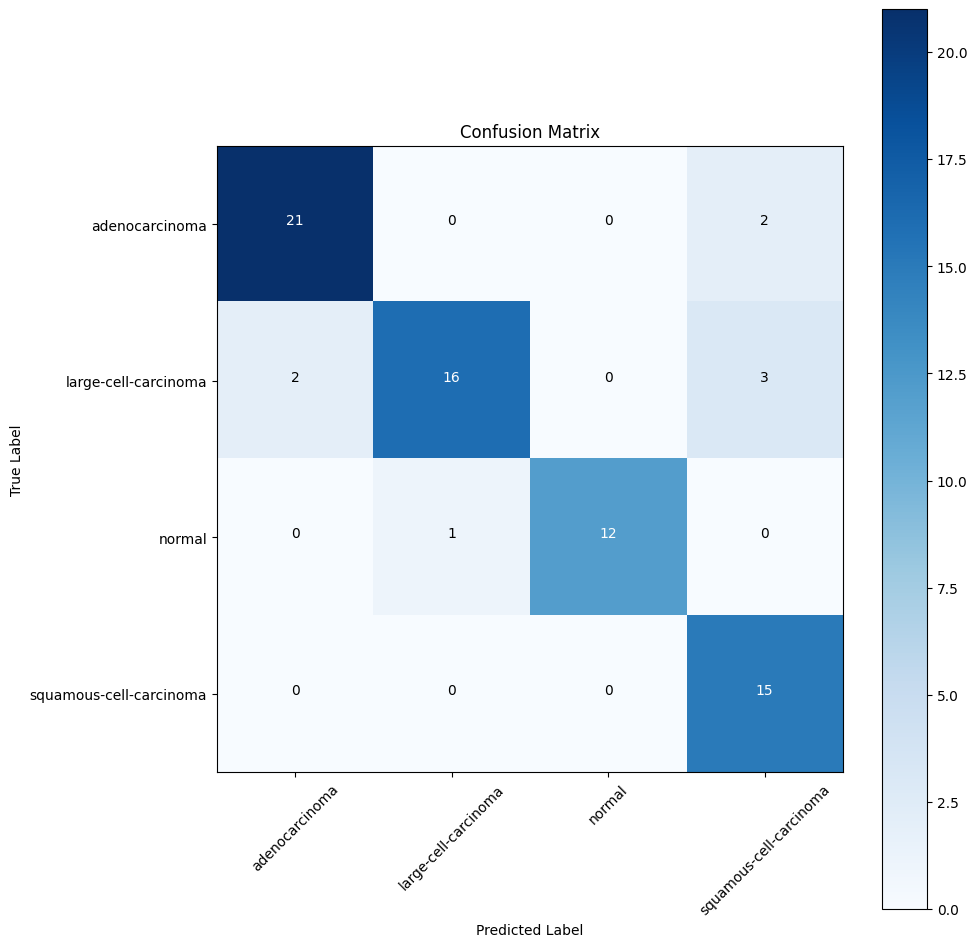

In [ ]:
 from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

target_names = ['adenocarcinoma', 'large-cell-carcinoma', 'normal', 'squamous-cell-carcinoma']
# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)
plot_confusion_matrix(cm= cm, classes= target_names, title = 'Confusion Matrix')
# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= target_names))

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

target_names = ['adenocarcinoma', 'large-cell-carcinoma', 'normal', 'squamous-cell-carcinoma']
img = image.load_img("istockphoto-1140845002-1024x1024.jpg", target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

pred = model.predict(img_array)

print("Prediction probabilities:", pred)
print("Predicted class:", target_names[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction probabilities: [[0.0656806  0.19103162 0.0831961  0.66009176]]
Predicted class: squamous-cell-carcinoma
